In [1]:
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
import onep

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

In [3]:
# Define animals for each group
mouse_ids = ['astroF3', 'astroF5', 'astroF6', 'astroF7', 'astroF8', 'astroF9', 'astroF10',
             'astroM3', 'astroM4', 'astroM5', 'astroM6', 'astroM7', 'astroM8', 'astroM9', 'astroM10']

In [4]:
#Grab your mice and take accepted traces - convert to numpy arrays within mouse_id variable names
for mouse_id in mouse_ids:
    try:
        traces = collection_fc.animals[mouse_id].accepted_traces.to_numpy()
        globals()[mouse_id] = traces[:3303, :]
        print(f"Created variable {mouse_id} with shape {globals()[mouse_id].shape}")
    except Exception as e:
        print(f"Error loading {mouse_id}: {e}")

Created variable astroF3 with shape (3303, 125)
Created variable astroF5 with shape (3303, 195)
Created variable astroF6 with shape (3303, 191)
Created variable astroF7 with shape (3303, 130)
Created variable astroF8 with shape (3303, 309)
Created variable astroF9 with shape (3303, 291)
Created variable astroF10 with shape (3303, 204)
Created variable astroM3 with shape (3303, 165)
Created variable astroM4 with shape (3303, 275)
Created variable astroM5 with shape (3303, 288)
Created variable astroM6 with shape (3303, 177)
Created variable astroM7 with shape (3303, 253)
Created variable astroM8 with shape (3303, 239)
Created variable astroM9 with shape (3303, 115)
Created variable astroM10 with shape (3303, 175)


In [38]:
def run_cross_validated_analysis(
    animal_id, traces, timestamps, save_path_prefix,
    do_shuffle=True, n_shuffles=10000, seed=None, two_sided=True
):
    # ---------------- helpers ----------------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            if r_obs >= 0:
                p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
            else:
                p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    # ---------------- analysis ----------------
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # Compute ETA for shocks 1&3 and 2&4
    whole_eta_13, time_13 = onep.eta_individual_cells(traces.T, timestamps, [[120, 240]], window=28)
    whole_eta_24, time_24 = onep.eta_individual_cells(traces.T, timestamps, [[180, 300]], window=28)

    # Z-score starting at 140
    adjusted_whole_eta_1_3 = stats.zscore(whole_eta_13[:, 140:], axis=1)
    adjusted_whole_eta_2_4 = stats.zscore(whole_eta_24[:, 140:], axis=1)
    time_1_3 = time_13[140:]

    # Sort arrays by max
    sorted_array_1, idxs_13 = onep.maxsort(adjusted_whole_eta_1_3)
    sorted_array_2, idxs_24 = onep.maxsort(adjusted_whole_eta_2_4)

    # y-ticks for heatmaps
    first_last = [0, len(adjusted_whole_eta_1_3)]

    # --- Heatmaps ---
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.heatmap(adjusted_whole_eta_1_3[idxs_13], ax=ax1, cmap='mako', cbar=False,
                xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax1.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax1.set_yticks(first_last)
    ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax1.set_title('Odd Shocks [1&3]', fontsize=10, pad=10)
    ax1.set_ylabel('Astrocyte #', fontsize=10)
    ax1.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax1, left=True, bottom=True)

    sns.heatmap(adjusted_whole_eta_1_3[idxs_24], ax=ax2, cmap='mako', cbar=True,
                cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax2.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax2.set_yticks(first_last)
    ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax2.set_title('Odd Shocks [1&3] sorted by Even Shocks [2&4]', fontsize=10, pad=10)
    ax2.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax2, left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # --- Argmaxes ---
    max_idxs_1_3 = np.argmax(sorted_array_1, axis=1)
    argmax_1_3 = time_1_3[max_idxs_1_3]

    odd_sorted_even = adjusted_whole_eta_1_3[idxs_24]
    sorted_idx = np.argmax(odd_sorted_even, axis=1)
    argmax_1_3_sorted_2_4 = time_1_3[sorted_idx]

    # --- Spearman correlation ---
    rho_s, p_s = stats.spearmanr(argmax_1_3, argmax_1_3_sorted_2_4)
    print(f"{animal_id} - Spearman rho: {rho_s:.4f}, p-value: {p_s:.4e}")

    # --- Shuffle control (optional) ---
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_1_3, argmax_1_3_sorted_2_4,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        print(f"{animal_id} - shuffle null: mean={shres['null_mean']:.4f}, "
              f"sd={shres['null_std']:.4f}, empirical p={shres['p_empirical']:.4g}, "
              f"z={shres['z_obs_vs_null']:.2f}")
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # --- Regression data (clean) ---
    df = pd.DataFrame({
        'Argmax Odds sorted Odds': argmax_1_3,
        'Argmax Odds sorted Evens': argmax_1_3_sorted_2_4
    })
    x_name = 'Argmax Odds sorted Odds'
    y_name = 'Argmax Odds sorted Evens'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()
    X = sm.add_constant(x)

    # --- Fit RLM ---
    model = sm.RLM(y, X).fit()

    # ---- R^2 variants ----
    y_pred = np.asarray(model.fittedvalues)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # guard for degenerate correlation
    try:
        r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
    except Exception:
        r2_corr = np.nan

    rho_rlm = model.model.M.rho
    scale = getattr(model, "scale", 1.0) or 1.0
    resid_fit_scaled = (y - y_pred) / scale
    resid_null_scaled = (y - float(np.mean(y))) / scale
    loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
    loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
    r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

    # ---- Extract flattened params ----
    beta  = np.asarray(model.params)        # [intercept, slope]
    pvals = np.asarray(model.pvalues)       # [p_intercept, p_slope]
    intercept = float(beta[0]) if beta.size > 0 else np.nan
    slope     = float(beta[1]) if beta.size > 1 else np.nan
    p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
    p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

    # --- Plot: scatter + RLM line + 95% CI (bootstrap with fallback) ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

    x_grid = np.linspace(x.min(), x.max(), 200)
    X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X_grid @ np.asarray(model.params)
    ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

    n_boot = 1000
    min_ok = 100
    rng = np.random.default_rng(12345)
    y_boot = np.full((n_boot, x_grid.size), np.nan, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, len(_df), size=len(_df))
        xb = x[idx]; yb = y[idx]
        Xb = sm.add_constant(xb)
        try:
            mb = sm.RLM(yb, Xb).fit()
            y_boot[b, :] = X_grid @ np.asarray(mb.params)
        except Exception:
            pass

    counts = np.sum(np.isfinite(y_boot), axis=0)
    lower = np.full_like(y_hat, np.nan)
    upper = np.full_like(y_hat, np.nan)
    ok = counts >= min_ok
    if np.any(ok):
        lower[ok] = np.nanpercentile(y_boot[:, ok], 2.5, axis=0)
        upper[ok] = np.nanpercentile(y_boot[:, ok], 97.5, axis=0)

    if np.any(~ok):
        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z = stats.norm.ppf(0.975)
        lower_analytic = y_hat - z * se_mean
        upper_analytic = y_hat + z * se_mean
        lower[~ok] = lower_analytic[~ok]
        upper[~ok] = upper_analytic[~ok]

    ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
    ax.set_xlabel('Argmax Odds Sorted Odds (s)', fontsize=10, fontname="Arial")
    ax.set_ylabel('Argmax Odds Sorted Evens (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 25)
    ax.set_xlim(0, 25)
    sns.despine(ax=ax)
    ax.legend(frameon=False)

    scatter_fp = f"{save_path_prefix}_scatter.svg"
    fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---- Return flattened summary ----
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }

In [39]:
# ===================== batch runner =====================

trace_lookup = {mouse: globals()[mouse] for mouse in mouse_ids}

all_results = []
save_dir = '/Users/ryansenne/Downloads'

for mouse in mouse_ids:
    print(f"Processing {mouse}...")
    traces = trace_lookup[mouse]
    timestamps = collection_fc.animals[mouse].Timestamps[:3303]
    res = run_cross_validated_analysis(
        animal_id=mouse,
        traces=traces,
        timestamps=timestamps,
        save_path_prefix=f"{save_dir}/FC_crossvalled_{mouse}"
    )
    all_results.append(res)

df_all_results = pd.DataFrame(all_results)

# put 'animal' first if present
if 'animal' in df_all_results.columns:
    cols = ['animal'] + [c for c in df_all_results.columns if c != 'animal']
    df_all_results = df_all_results[cols]

print(df_all_results)
df_all_results.to_csv(f'{save_dir}/crossval_summary_results.csv', index=False)
print(f"Saved: {save_dir}/crossval_summary_results.csv")

Processing astroF3...
astroF3 - Spearman rho: 0.5106, p-value: 1.1733e-09
astroF3 - shuffle null: mean=-0.0002, sd=0.0896, empirical p=9.999e-05, z=5.70
Processing astroF5...
astroF5 - Spearman rho: 0.5812, p-value: 5.1628e-19
astroF5 - shuffle null: mean=0.0019, sd=0.0710, empirical p=9.999e-05, z=8.16
Processing astroF6...
astroF6 - Spearman rho: 0.7504, p-value: 8.0862e-36
astroF6 - shuffle null: mean=-0.0004, sd=0.0723, empirical p=9.999e-05, z=10.39
Processing astroF7...
astroF7 - Spearman rho: 0.7853, p-value: 1.9744e-28
astroF7 - shuffle null: mean=0.0007, sd=0.0884, empirical p=9.999e-05, z=8.87
Processing astroF8...
astroF8 - Spearman rho: 0.4951, p-value: 1.6180e-20
astroF8 - shuffle null: mean=-0.0005, sd=0.0573, empirical p=9.999e-05, z=8.66
Processing astroF9...
astroF9 - Spearman rho: 0.6760, p-value: 3.3213e-40
astroF9 - shuffle null: mean=0.0004, sd=0.0587, empirical p=9.999e-05, z=11.51
Processing astroF10...
astroF10 - Spearman rho: 0.7284, p-value: 5.1699e-35
astroF1

In [22]:
df_all_results

,animal,spearman_rho,spearman_p,regression_results,heatmap_fp,scatter_fp,shuffle_hist_fp,shuffle_empirical_p,shuffle_null_mean,shuffle_null_std,shuffle_z
0,astroF3,0.510634,1.173288e-09,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,-0.000244,0.089593,5.702231
1,astroF5,0.581240,5.162773e-19,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.001922,0.071036,8.155240
2,astroF6,0.750361,8.086209e-36,animal slope intercept p_value_slope ...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,-0.000407,0.072254,10.390613
3,astroF7,0.785315,1.974361e-28,animal slope intercept p_value_slope ...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.000731,0.088413,8.874071
4,astroF8,0.495146,1.618007e-20,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,-0.000525,0.057262,8.656170
5,astroF9,0.675997,3.321308e-40,animal slope intercept p_value_slope ...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.000396,0.058702,11.508956
6,astroF10,0.728400,5.169854e-35,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.001143,0.070524,10.312222
7,astroM3,0.506051,4.098896e-12,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.000210,0.078147,6.472961
8,astroM4,0.566034,1.072612e-24,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,0.000488,0.060391,9.364705
9,astroM5,0.486959,1.484713e-18,animal slope intercept p_value_slope...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,/Users/ryansenne/Downloads/FC_crossvalled_astr...,0.0001,-0.000263,0.059118,8.241543


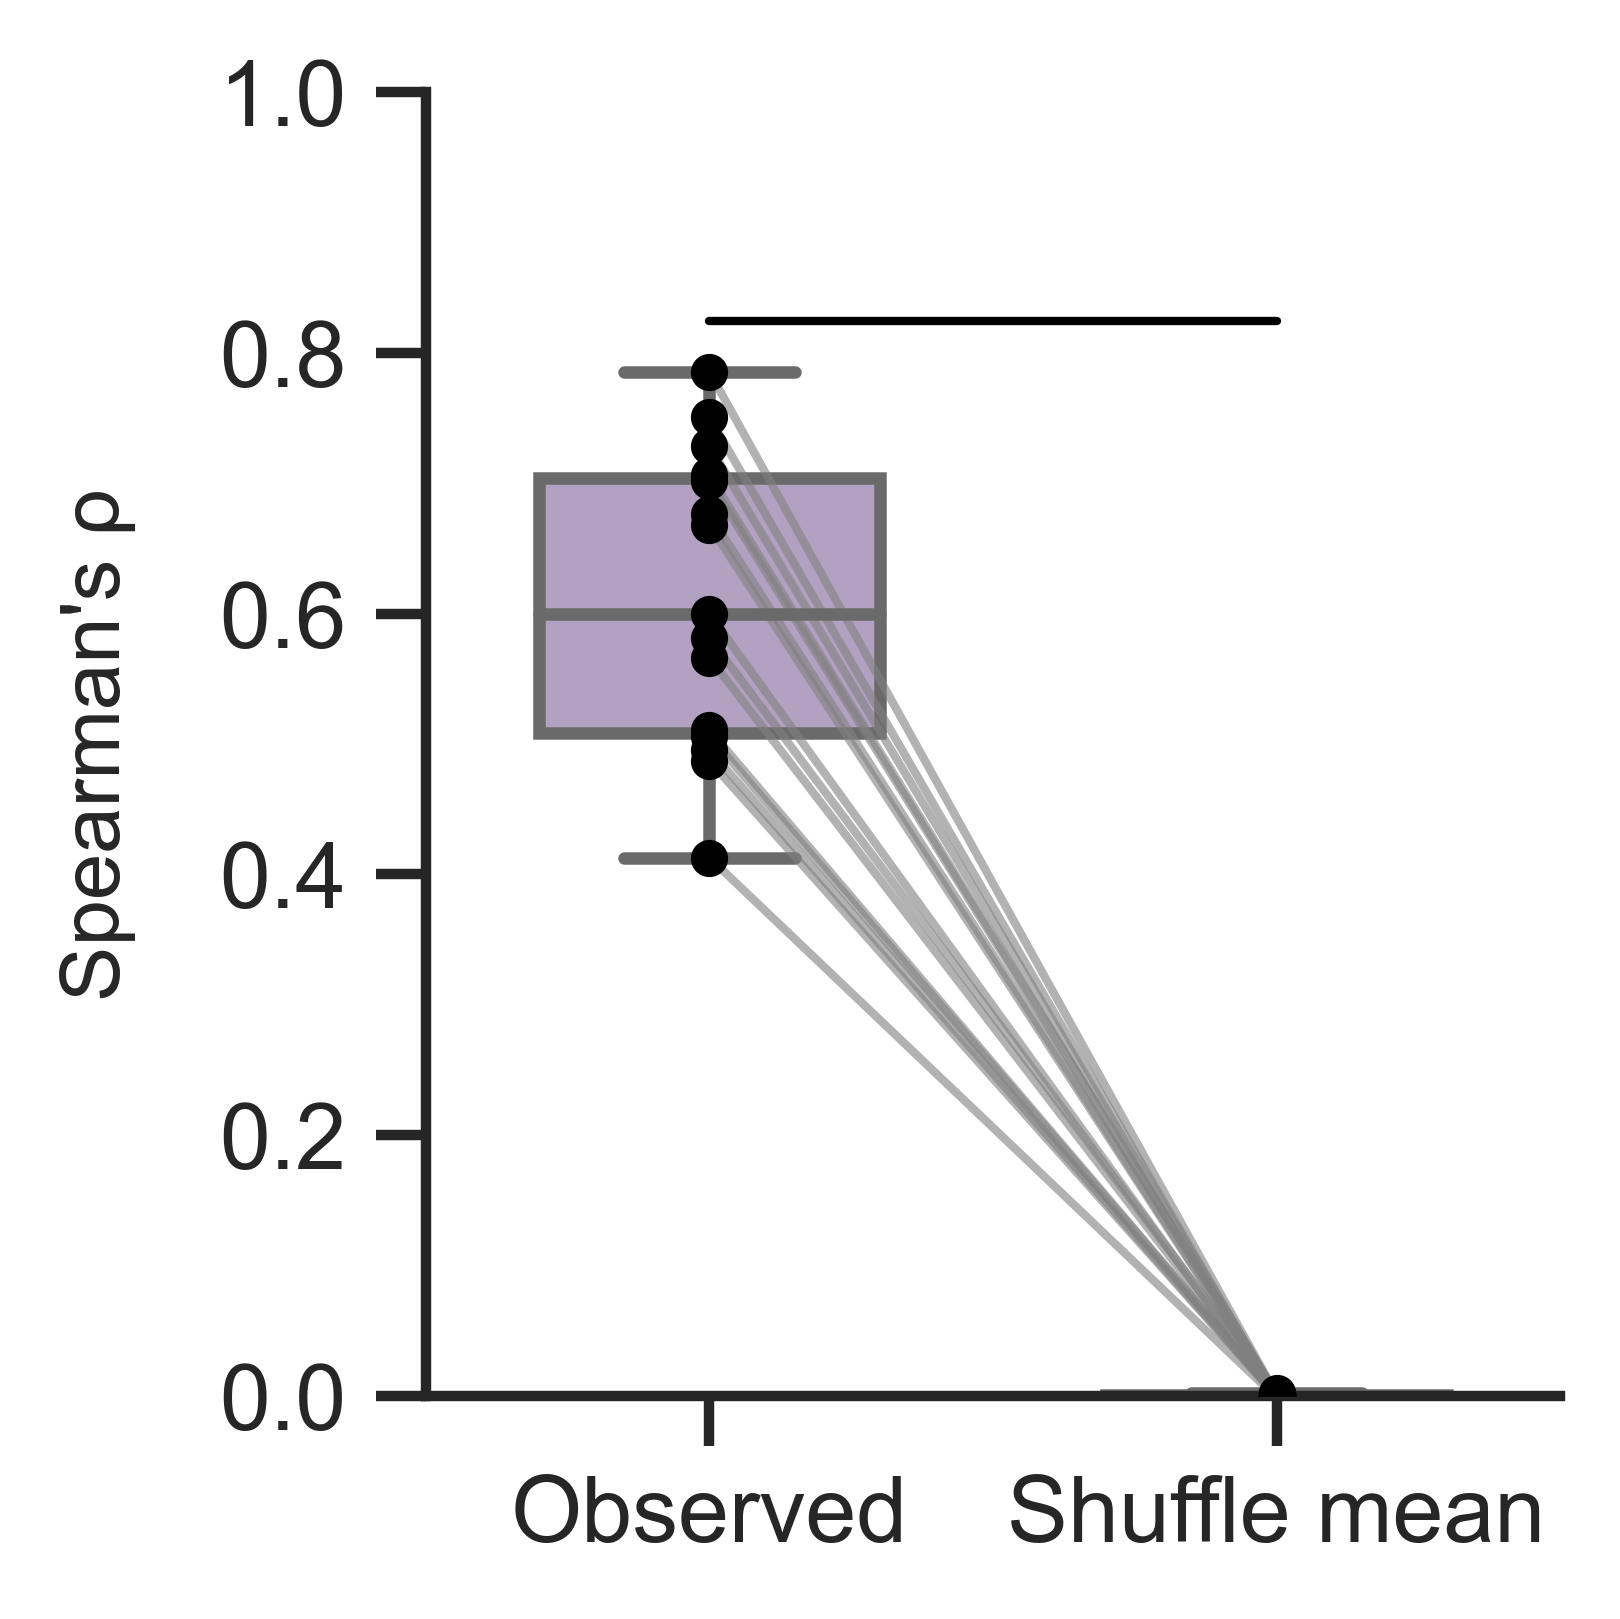

In [40]:
from scipy.stats import ttest_rel

def plot_spearman_rho_paired(
    df,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal",
    title="",
    save_path=None
):
    """
    Draws side-by-side boxplots of observed Spearman rho vs shuffle-mean rho,
    overlays paired points per animal connected by line segments,
    and annotates a paired t-test.

    Expects df to have columns: [id_col, obs_col, null_col].
    """
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial', 'figure.figsize': (3.5, 3.5)})
    sns.set(style="ticks", font="Arial")

    # Keep rows with both values present
    d = df[[id_col, obs_col, null_col]].dropna().copy()
    if d.empty:
        raise ValueError("No rows with both observed and shuffle mean rhos present.")

    # Paired t-test
    tstat, pval = ttest_rel(d[obs_col], d[null_col])

    # Long form for plotting
    long = d.melt(
        id_vars=id_col,
        value_vars=[obs_col, null_col],
        var_name="condition",
        value_name="rho"
    )
    name_map = {obs_col: "Observed", null_col: "Shuffle mean"}
    long["condition"] = long["condition"].map(name_map)

    order = ["Observed", "Shuffle mean"]  # left→right
    palette = {"Observed": "#B39BC8", "Shuffle mean": "#C9D6DF"}  # keep your original purple

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Boxplots (background)
    sns.boxplot(
        data=long, x="condition", y="rho",
        order=order, palette=palette, ax=ax,
        width=0.6, showfliers=False
    )

    # Connect each animal’s pair and plot points
    x_pos = {cond: i for i, cond in enumerate(order)}
    for animal, grp in long.groupby(id_col):
        if set(order).issubset(set(grp["condition"])):
            y0 = grp.loc[grp["condition"] == "Shuffle mean", "rho"].values[0]
            y1 = grp.loc[grp["condition"] == "Observed", "rho"].values[0]
            ax.plot(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                color="gray", alpha=0.6, linewidth=1, zorder=2
            )
            ax.scatter(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                s=12, color="black", zorder=3
            )

    # Axis labels, limits, title
    ax.set_ylabel("Spearman's ρ", fontsize=10, fontname='Arial', labelpad=10)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.set_ylim(0, 1)

    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bar + text
    y_max = long["rho"].max()
    y_min = long["rho"].min()
    span = max(1e-6, y_max - y_min)
    y_bar = y_max + 0.05 * span
    ax.plot([x_pos["Shuffle mean"], x_pos["Observed"]], [y_bar, y_bar], color="black", linewidth=1)

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (tstat, pval)

fig, ax, (t, p) = plot_spearman_rho_paired(
    df_all_results,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal"
)

plt.savefig('/Users/ryansenne/Downloads/FC_crossval_rho_paired.svg', dpi=600, bbox_inches='tight', format='svg')

In [8]:
from scipy.stats import ttest_1samp

rhos = df_all_results['spearman_rho']
t_stat, p_val = ttest_1samp(rhos, 0)

print(f"One-sample t-test against zero:")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")


One-sample t-test against zero:
t-statistic = 20.859, p-value = 0.0000


In [5]:
# def sequence_heat_plot(unsorted_array, time, ax=None):
#     """
#     arr: N x T array of cell activity
#     time: T array of time
#     returns: ax
#     """
#     # z-score array
#     arr = stats.zscore(unsorted_array, axis=1)
#     # sort array based on argmax of each row
#     arr, _ = onep.maxsort(arr)
#     # make a figure
#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(5, 5))
#     # plot the heatmap
#     sns.heatmap(arr, cmap='mako',cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"})
#     # set x-ticks
#     ax.set_xticks(np.linspace(0, arr.shape[1], 5), np.linspace(np.min(time), np.max(time), 5))
#     # ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
#     ax.axvline((time.shape[0]/3), linestyle='--', color='white')
#     # set labels
#     ax.set_xlabel('Time (s)')
#     ax.set_ylabel('Cells')
#     plt.tight_layout()
#     return ax, fig

In [3]:
# # # make sorted heatmaps for fc at time of shocks - average; z-scored; window=28
# # for annie in [astro_4]:
# #     whole_eta, time = annie.eta_individual_cells([[120,180,240,300]], window=28)
# #     sequence_heat_plot(whole_eta, time)
# #     plt.savefig(f"/Users/suthardr/Desktop/{annie.animal}_sorted_heat_plot_avg.png")

AttributeError: 'DataFrame' object has no attribute 'eta_individual_cells'

In [86]:
# # make_cross_validated plots - FC
#
# # for annie in [collection_cxta_fc.animals['astro3'].accepted_traces]:
# whole_eta_13, time_13 = onep.eta_individual_cells(astroF3.T, collection_fc.animals['astroF3'].Timestamps[:3303], [[120, 240]], window=28)
# whole_eta_24, time_24 = onep.eta_individual_cells(astroF3.T, collection_fc.animals['astroF3'].Timestamps[:3303], [[180, 300]], window=28)

In [87]:
# whole_eta_13

array([[ 1.77531849e-03,  1.66382562e-03,  2.20616476e-03, ...,
         1.33616505e-03,  1.30092978e-04, -6.41163480e-05],
       [ 4.75372897e-03,  3.51854380e-03,  3.02096710e-03, ...,
         1.59529111e-03,  1.62010220e-03,  3.16181721e-03],
       [ 2.50729477e-03,  1.80503889e-03,  1.49886831e-03, ...,
         2.18984215e-03,  3.96421626e-03,  3.07355439e-03],
       ...,
       [ 4.39803388e-03,  4.70729366e-03,  5.05042648e-03, ...,
         4.67923769e-03,  4.17809918e-03,  5.09716897e-03],
       [ 1.44415574e-03,  1.65929478e-03,  1.90610579e-03, ...,
         2.88313456e-03,  2.86441627e-03,  3.83131740e-03],
       [ 5.34705519e-03,  5.72470456e-03,  5.30583018e-03, ...,
         1.06765924e-03,  8.68472609e-04,  9.16416066e-04]])

In [88]:
# # # z_score the data
# adjusted_whole_eta_1_3 = stats.zscore(whole_eta_13[:, 140:], axis=1)
# adjusted_whole_eta_2_4 = stats.zscore(whole_eta_24[:, 140:], axis=1)
# time_1_3 = time_13[140:]
# time_2_4 = time_24[140:]

In [89]:
# # now get indices for cross validation
# sorted_array_1, idxs_13 = onep.maxsort(adjusted_whole_eta_1_3)
# sorted_array_2, idxs_24 = onep.maxsort(adjusted_whole_eta_2_4)
#
# # now make heat map for cross-validated 2&4 vs. 1&3
# # onep.cross_validated_heat_plot(unsorted_array=whole_eta_1_3, idxes_to_sort=idxs_13, sorted_array=sorted_array_1, time=time_1_3)
# # onep.cross_validated_heat_plot(unsorted_array=whole_eta_2_4, idxes_to_sort=idxs_13, sorted_array=sorted_array_1, time=time_1_3)
# # plt.savefig(f"/Users/suthardr/Desktop/{annie.animal}_cross_validated_heat_plot.png")

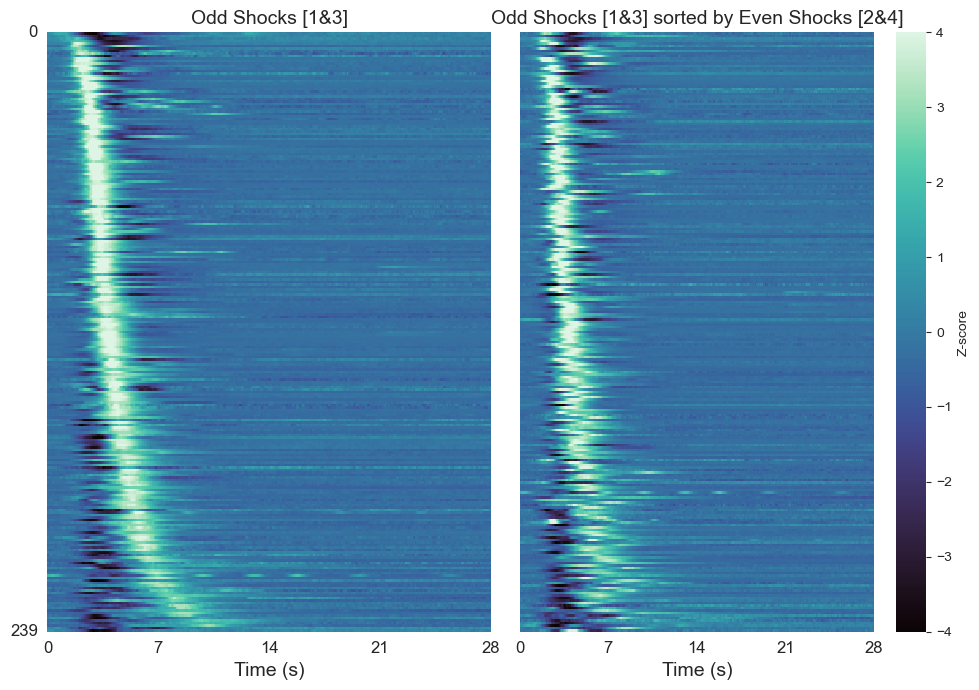

In [90]:
# import matplotlib.pyplot as plt
# import seaborn as sns
#
# first_last1_3 = [0, len(adjusted_whole_eta_1_3)]
# first_last2_4 = [0, len(adjusted_whole_eta_2_4)]
#
# # Create a figure and axes with a shared y-axis
# fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10, 7))
#
# # Plot heatmap for the first dataset (1&3)
# sns.heatmap(adjusted_whole_eta_1_3[idxs_13], ax=ax1, cmap='mako', cbar=False,
#             cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized = True, yticklabels=True, vmin=-4, vmax=4)
# # ax1.axvline((time_1_3.shape[0] / 3), linestyle='--', color='white')
# ax1.tick_params(axis='both', which='major', labelsize=12)
# ax1.set_xticks(np.linspace(0, len(time_1_3), 5))
# ax1.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
# ax1.set_yticks(first_last1_3)  # Set y-ticks to first and last indices
# ax1.set_yticklabels([first_last1_3[0], first_last1_3[1]], rotation=0)  # Label y-ticks
# ax1.set_title('Odd Shocks [1&3]', fontsize=14)
# ax1.set_xlabel('Time (s)', fontsize=14)
#
# # Plot heatmap for the second dataset (2&4)
# sns.heatmap(adjusted_whole_eta_1_3[idxs_24], ax=ax2, cmap='mako', cbar=True,
#             cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized= True, yticklabels=True, vmin=-4, vmax=4)
# # ax2.axvline((time_1_3.shape[0] / 3), linestyle='--', color='white')
# ax2.tick_params(axis='both', which='major', labelsize=12)
# ax2.set_xticks(np.linspace(0, len(time_1_3), 5))
# ax2.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
# ax2.set_yticks(first_last1_3)  # Set y-ticks to first and last indices
# ax2.set_yticklabels([first_last1_3[0], first_last1_3[1]], rotation=0)  # Label y-ticks
# ax2.set_title('Odd Shocks [1&3] sorted by Even Shocks [2&4]', fontsize=14)
# ax2.set_xlabel('Time (s)', fontsize=14)
#
# # Adjust layout
# plt.tight_layout()
#
# # Show the plot
# fig.savefig('/Users/suthardr/Desktop/Rui_Newest_Model_July/FC_argmax_crossvalled/FC_crossvalled_heatmap_astro8.svg')

In [91]:
# max_idxs_1_3 = np.zeros(sorted_array_1.shape[0], dtype=int)
#
# # # Iterate over each row of across_eta_ to find the maximum index
# for i in range(sorted_array_1.shape[0]):
#     idx = np.argmax(sorted_array_1[i])
#     max_idxs_1_3[i] = idx
# max_idxs_1_3

array([  7,  12,  18,  18,  18,  18,  19,  19,  21,  21,  21,  21,  21,
        22,  22,  22,  22,  23,  24,  24,  25,  25,  25,  25,  26,  26,
        26,  26,  26,  26,  26,  26,  27,  27,  27,  27,  27,  28,  28,
        28,  28,  28,  28,  28,  28,  28,  29,  29,  29,  29,  29,  29,
        29,  29,  30,  30,  30,  31,  31,  31,  31,  31,  31,  31,  31,
        31,  31,  32,  32,  32,  32,  32,  32,  32,  32,  33,  33,  33,
        33,  33,  33,  33,  33,  33,  33,  33,  33,  34,  34,  34,  34,
        34,  34,  34,  34,  34,  34,  34,  34,  35,  35,  35,  35,  35,
        35,  36,  36,  36,  36,  36,  36,  36,  37,  37,  37,  37,  38,
        38,  38,  38,  38,  38,  38,  38,  38,  39,  39,  39,  40,  40,
        40,  40,  40,  41,  41,  41,  41,  41,  41,  42,  42,  42,  42,
        42,  43,  43,  43,  43,  43,  43,  44,  44,  44,  44,  44,  45,
        45,  45,  45,  45,  46,  46,  47,  47,  47,  47,  48,  48,  49,
        50,  50,  50,  50,  50,  51,  51,  51,  51,  51,  51,  5

In [92]:
# # Now, use max_idxs to index into the time array
# argmax_1_3 = time_1_3[max_idxs_1_3]
# argmax_1_3

array([ 0.73508353,  1.23627685,  1.83770883,  1.83770883,  1.83770883,
        1.83770883,  1.93794749,  1.93794749,  2.13842482,  2.13842482,
        2.13842482,  2.13842482,  2.13842482,  2.23866348,  2.23866348,
        2.23866348,  2.23866348,  2.33890215,  2.43914081,  2.43914081,
        2.53937947,  2.53937947,  2.53937947,  2.53937947,  2.63961814,
        2.63961814,  2.63961814,  2.63961814,  2.63961814,  2.63961814,
        2.63961814,  2.63961814,  2.7398568 ,  2.7398568 ,  2.7398568 ,
        2.7398568 ,  2.7398568 ,  2.84009547,  2.84009547,  2.84009547,
        2.84009547,  2.84009547,  2.84009547,  2.84009547,  2.84009547,
        2.84009547,  2.94033413,  2.94033413,  2.94033413,  2.94033413,
        2.94033413,  2.94033413,  2.94033413,  2.94033413,  3.04057279,
        3.04057279,  3.04057279,  3.14081146,  3.14081146,  3.14081146,
        3.14081146,  3.14081146,  3.14081146,  3.14081146,  3.14081146,
        3.14081146,  3.14081146,  3.24105012,  3.24105012,  3.24

In [93]:
# odd_sorted_even = adjusted_whole_eta_1_3[idxs_24]
# sorted_idx = np.zeros(odd_sorted_even.shape[0], dtype=int)
#
# # # Iterate over each row of across_eta_ to find the maximum index
# for i in range(odd_sorted_even.shape[0]):
#     idx = np.argmax(odd_sorted_even[i])
#     sorted_idx[i] = idx
#
# # Now, use max_idxs to index into the time array
# argmax_1_3_sorted_2_4 = time_1_3[sorted_idx]
# argmax_1_3_sorted_2_4

array([ 1.93794749, 10.1575179 ,  1.93794749,  1.83770883,  2.63961814,
        5.54653938,  1.83770883,  6.64916468,  4.24343675,  5.94749403,
        2.23866348,  2.13842482,  5.94749403,  2.63961814,  2.23866348,
        2.94033413,  1.83770883,  2.33890215,  2.53937947,  2.13842482,
        2.53937947,  2.23866348,  2.13842482,  4.24343675,  2.7398568 ,
        2.63961814,  2.84009547,  3.24105012,  2.84009547,  2.53937947,
        3.14081146,  2.84009547,  2.7398568 ,  3.14081146,  2.7398568 ,
        3.44152745,  2.94033413,  2.43914081,  3.64200477,  3.14081146,
        3.34128878,  2.63961814,  2.94033413,  2.53937947,  3.34128878,
        2.84009547,  3.24105012,  2.94033413,  3.24105012,  2.84009547,
        2.94033413,  3.44152745,  2.13842482,  2.84009547,  3.14081146,
        2.7398568 ,  3.44152745,  3.14081146,  3.24105012,  3.44152745,
        3.14081146,  2.63961814,  2.13842482,  4.54415274,  3.34128878,
        3.74224344,  4.14319809,  3.44152745,  3.54176611,  2.84

In [94]:
# rho, p = stats.spearmanr(argmax_1_3,argmax_1_3_sorted_2_4,axis=None)
# print("Formatted p-value: {:.20f}".format(p),
#       "Formatted rho: {:.20f}".format(rho))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Formatted p-value: 0.00000000000000000000 Formatted rho: 0.70621629205823077680


In [95]:
# import pandas as pd
# import numpy as np
#
# # Create a DataFrame from the arrays
# df = pd.DataFrame({
#     'Argmax Odds sorted Odds': argmax_1_3,
#     'Argmax Odds sorted Evens': argmax_1_3_sorted_2_4
# })
#
# print(df)
#

     Argmax Odds sorted Odds  Argmax Odds sorted Evens
0                   0.735084                  1.937947
1                   1.236277                 10.157518
2                   1.837709                  1.937947
3                   1.837709                  1.837709
4                   1.837709                  2.639618
..                       ...                       ...
234                 9.756563                  6.248210
235                10.157518                  1.236277
236                10.257757                  0.735084
237                16.372315                  8.353222
238                16.873508                  4.243437

[239 rows x 2 columns]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


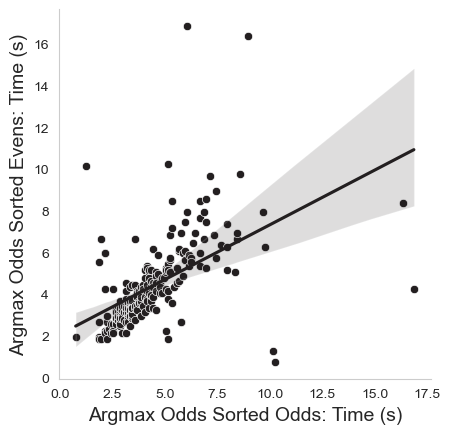

In [96]:
# import pandas as pd
# import statsmodels.api as sm
#
# animal = ['astro8']
# # x_min, x_max = 0, 15
# # y_min, y_max = 0, 15
#
# # create a datatable that has the animal, the slope, the intercept, and the p-values
# df_results = pd.DataFrame(columns=['animal', 'slope', 'intercept', 'p_value_slope', 'p_value_bias', 'r_squared'])
#
# # run regression on the data
# y = df['Argmax Odds sorted Evens']
# X = df['Argmax Odds sorted Odds']
# # add constant
# X = sm.add_constant(X)
# model = sm.OLS(y, X).fit()
# # append the animal name, slope, intercept, and p-value to the results dataframe
# df_results = pd.concat((df_results, pd.DataFrame({'animal': animal, 'slope': model.params['Argmax Odds sorted Odds'],
#                                     'intercept': model.params['const'], 'p_value_slope': model.pvalues['Argmax Odds sorted Odds'], "p_value_bias": model.pvalues["const"], "r_squared": model.rsquared}, index=[0])),
#                                     ignore_index=True)
# # generate a plot and save for each animal
# # Plot the scatter plot and the regression line
# fig, ax = plt.subplots(figsize=(4.8, 4.8))
#
# ax.grid(False)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ##75bfaa
# sns.scatterplot(data=df, x='Argmax Odds sorted Odds', y='Argmax Odds sorted Evens', c='#231f20', ax=ax)
# sns.regplot(data=df, x='Argmax Odds sorted Odds', y='Argmax Odds sorted Evens', color='#231f20', ax=ax, scatter=False, ci=95)
# # Set axis limits and labels
# # ax.set_xlim(x_min, x_max)
# # ax.set_ylim(y_min, y_max)
# ax.set_xlabel('Argmax Odds Sorted Odds: Time (s)', fontsize=14)
# ax.set_ylabel('Argmax Odds Sorted Evens: Time (s)', fontsize=14)
#
# # save fig
# fig.savefig('/Users/suthardr/Desktop/Rui_Newest_Model_July/FC_argmax_crossvalled/FC_crossvalled_scatter_astro8.svg')
#
#

In [174]:
# import matplotlib
# matplotlib.matplotlib_fname()

'/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc'

In [97]:
# df_results

,animal,slope,intercept,p_value_slope,p_value_bias,r_squared
0,astro8,0.524961,2.071781,2.499616e-18,2.155988e-13,0.275585


In [5]:
def run_cross_validated_analysis_first_second_half(
    animal_id, traces, timestamps, save_path_prefix,
    do_shuffle=True, n_shuffles=10000, seed=None, two_sided=True
):
    # ---------------- helpers ----------------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x); y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            if r_obs >= 0:
                p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
            else:
                p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    # ---------------- analysis ----------------
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # Compute ETA for shocks 1&3 and 2&4
    whole_eta_13, time_13 = onep.eta_individual_cells(traces.T, timestamps, [[120, 180]], window=28)
    whole_eta_24, time_24 = onep.eta_individual_cells(traces.T, timestamps, [[240, 300]], window=28)

    # Z-score starting at 140
    adjusted_whole_eta_1_3 = stats.zscore(whole_eta_13[:, 140:], axis=1)
    adjusted_whole_eta_2_4 = stats.zscore(whole_eta_24[:, 140:], axis=1)
    time_1_3 = time_13[140:]

    # Sort arrays by max
    sorted_array_1, idxs_13 = onep.maxsort(adjusted_whole_eta_1_3)
    sorted_array_2, idxs_24 = onep.maxsort(adjusted_whole_eta_2_4)

    # y-ticks for heatmaps
    first_last = [0, len(adjusted_whole_eta_1_3)]

    # --- Heatmaps ---
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.heatmap(adjusted_whole_eta_1_3[idxs_13], ax=ax1, cmap='mako', cbar=False,
                xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax1.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax1.set_yticks(first_last)
    ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax1.set_title('First Half (1&2)', fontsize=10, pad=10)
    ax1.set_ylabel('Astrocyte #', fontsize=10)
    ax1.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax1, left=True, bottom=True)

    sns.heatmap(adjusted_whole_eta_1_3[idxs_24], ax=ax2, cmap='mako', cbar=True,
                cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax2.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax2.set_yticks(first_last)
    ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax2.set_title('First Half Sorted by Second Half', fontsize=10, pad=10)
    ax2.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax2, left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # --- Argmaxes ---
    max_idxs_1_3 = np.argmax(sorted_array_1, axis=1)
    argmax_1_3 = time_1_3[max_idxs_1_3]

    odd_sorted_even = adjusted_whole_eta_1_3[idxs_24]
    sorted_idx = np.argmax(odd_sorted_even, axis=1)
    argmax_1_3_sorted_2_4 = time_1_3[sorted_idx]

    # --- Spearman correlation ---
    rho_s, p_s = stats.spearmanr(argmax_1_3, argmax_1_3_sorted_2_4)
    print(f"{animal_id} - Spearman rho: {rho_s:.4f}, p-value: {p_s:.4e}")

    # --- Shuffle control (optional) ---
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_1_3, argmax_1_3_sorted_2_4,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        print(f"{animal_id} - shuffle null: mean={shres['null_mean']:.4f}, "
              f"sd={shres['null_std']:.4f}, empirical p={shres['p_empirical']:.4g}, "
              f"z={shres['z_obs_vs_null']:.2f}")
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # --- Regression data (clean) ---
    df = pd.DataFrame({
        'Argmax First sorted First': argmax_1_3,
        'Argmax First sorted Second': argmax_1_3_sorted_2_4
    })
    x_name = 'Argmax First sorted First'
    y_name = 'Argmax First sorted Second'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()
    X = sm.add_constant(x)

    # --- Fit RLM ---
    model = sm.RLM(y, X).fit()

    # ---- R^2 variants ----
    y_pred = np.asarray(model.fittedvalues)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # guard for degenerate correlation
    try:
        r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
    except Exception:
        r2_corr = np.nan

    rho_rlm = model.model.M.rho
    scale = getattr(model, "scale", 1.0) or 1.0
    resid_fit_scaled = (y - y_pred) / scale
    resid_null_scaled = (y - float(np.mean(y))) / scale
    loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
    loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
    r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

    # ---- Extract flattened params ----
    beta  = np.asarray(model.params)        # [intercept, slope]
    pvals = np.asarray(model.pvalues)       # [p_intercept, p_slope]
    intercept = float(beta[0]) if beta.size > 0 else np.nan
    slope     = float(beta[1]) if beta.size > 1 else np.nan
    p_value_bias  = float(pvals[0]) if pvals.size > 0 else np.nan
    p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

    # --- Plot: scatter + RLM line + 95% CI (bootstrap with fallback) ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

    x_grid = np.linspace(x.min(), x.max(), 200)
    X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X_grid @ np.asarray(model.params)
    ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

    n_boot = 1000
    min_ok = 100
    rng = np.random.default_rng(12345)
    y_boot = np.full((n_boot, x_grid.size), np.nan, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, len(_df), size=len(_df))
        xb = x[idx]; yb = y[idx]
        Xb = sm.add_constant(xb)
        try:
            mb = sm.RLM(yb, Xb).fit()
            y_boot[b, :] = X_grid @ np.asarray(mb.params)
        except Exception:
            pass

    counts = np.sum(np.isfinite(y_boot), axis=0)
    lower = np.full_like(y_hat, np.nan)
    upper = np.full_like(y_hat, np.nan)
    ok = counts >= min_ok
    if np.any(ok):
        lower[ok] = np.nanpercentile(y_boot[:, ok], 2.5, axis=0)
        upper[ok] = np.nanpercentile(y_boot[:, ok], 97.5, axis=0)

    if np.any(~ok):
        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z = stats.norm.ppf(0.975)
        lower_analytic = y_hat - z * se_mean
        upper_analytic = y_hat + z * se_mean
        lower[~ok] = lower_analytic[~ok]
        upper[~ok] = upper_analytic[~ok]

    ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
    ax.set_xlabel('Argmax First Sorted First (s)', fontsize=10, fontname="Arial")
    ax.set_ylabel('Argmax First Sorted Second (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 25)
    ax.set_xlim(0, 25)
    sns.despine(ax=ax)
    ax.legend(frameon=False)

    scatter_fp = f"{save_path_prefix}_scatter.svg"
    fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---- Return flattened summary ----
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }

In [6]:
# ===================== batch runner =====================

trace_lookup = {mouse: globals()[mouse] for mouse in mouse_ids}

all_results = []
save_dir = '/Users/suthardr/Desktop/first_v_sesond'

for mouse in mouse_ids:
    print(f"Processing {mouse}...")
    traces = trace_lookup[mouse]
    timestamps = collection_fc.animals[mouse].Timestamps[:3303]
    res = run_cross_validated_analysis_first_second_half(
        animal_id=mouse,
        traces=traces,
        timestamps=timestamps,
        save_path_prefix=f"{save_dir}/FC_crossvalled_{mouse}"
    )
    all_results.append(res)

df_all_results = pd.DataFrame(all_results)

# put 'animal' first if present
if 'animal' in df_all_results.columns:
    cols = ['animal'] + [c for c in df_all_results.columns if c != 'animal']
    df_all_results = df_all_results[cols]

print(df_all_results)
df_all_results.to_csv(f'{save_dir}/crossval_summary_results.csv', index=False)
print(f"Saved: {save_dir}/crossval_summary_results.csv")

Processing astroF3...
astroF3 - Spearman rho: 0.5095, p-value: 1.2986e-09
astroF3 - shuffle null: mean=0.0003, sd=0.0908, empirical p=9.999e-05, z=5.61
Processing astroF5...
astroF5 - Spearman rho: 0.6914, p-value: 4.7120e-29
astroF5 - shuffle null: mean=0.0007, sd=0.0725, empirical p=9.999e-05, z=9.52
Processing astroF6...
astroF6 - Spearman rho: 0.8558, p-value: 5.2558e-56
astroF6 - shuffle null: mean=-0.0012, sd=0.0727, empirical p=9.999e-05, z=11.78
Processing astroF7...
astroF7 - Spearman rho: 0.7658, p-value: 2.6522e-26
astroF7 - shuffle null: mean=0.0002, sd=0.0885, empirical p=9.999e-05, z=8.65
Processing astroF8...
astroF8 - Spearman rho: 0.7034, p-value: 1.9487e-47
astroF8 - shuffle null: mean=0.0012, sd=0.0562, empirical p=9.999e-05, z=12.49
Processing astroF9...
astroF9 - Spearman rho: 0.6116, p-value: 2.9956e-31
astroF9 - shuffle null: mean=0.0000, sd=0.0585, empirical p=9.999e-05, z=10.45
Processing astroF10...
astroF10 - Spearman rho: 0.6188, p-value: 5.9863e-23
astroF10

In [7]:
df_all_results

,animal,spearman_rho,spearman_p,slope,intercept,p_value_slope,p_value_bias,r2_var,r2_corr,r2_pseudo_robust,heatmap_fp,scatter_fp,shuffle_hist_fp,shuffle_empirical_p,shuffle_null_mean,shuffle_null_std,shuffle_z
0,astroF3,0.509463,1.298614e-09,0.583715,1.133951,1.644753e-20,1.408531e-09,0.209878,0.224526,0.289563,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000254,0.090764,5.610266
1,astroF5,0.691362,4.711969e-29,0.781730,0.558286,2.545121e-82,5.895064e-07,0.514212,0.519783,0.500069,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000669,0.072526,9.523393
2,astroF6,0.855829,5.255834e-56,0.921923,0.144831,0.000000e+00,1.038691e-03,0.451433,0.498246,0.604863,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,-0.001154,0.072741,11.781312
3,astroF7,0.765754,2.652170e-26,0.819740,0.381739,7.071916e-114,2.473266e-05,0.559678,0.567222,0.514830,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000203,0.088514,8.648885
4,astroF8,0.703427,1.948721e-47,0.792970,0.838932,5.016317e-213,4.939447e-13,0.313722,0.353736,0.359852,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.001210,0.056214,12.491907
5,astroF9,0.611642,2.995585e-31,0.620797,1.257999,1.222540e-261,1.757359e-29,0.340535,0.365604,0.437422,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000050,0.058536,10.448220
6,astroF10,0.618818,5.986345e-23,0.623883,1.263787,0.000000e+00,6.899135e-41,0.401419,0.416754,0.440524,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000072,0.070295,8.802083
7,astroM3,0.618779,8.207016e-19,0.643717,1.310195,3.096061e-64,2.927358e-12,0.274643,0.291675,0.284656,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,-0.000575,0.077569,7.984520
8,astroM4,0.576192,1.004662e-25,0.617703,1.311028,1.175764e-76,1.397045e-20,0.259882,0.274434,0.315831,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000225,0.061090,9.428194
9,astroM5,0.499399,1.425480e-19,0.293860,2.601394,2.159047e-34,1.468825e-86,0.014448,0.044275,0.167286,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,/Users/suthardr/Desktop/first_v_sesond/FC_cros...,0.0001,0.000216,0.058588,8.520256


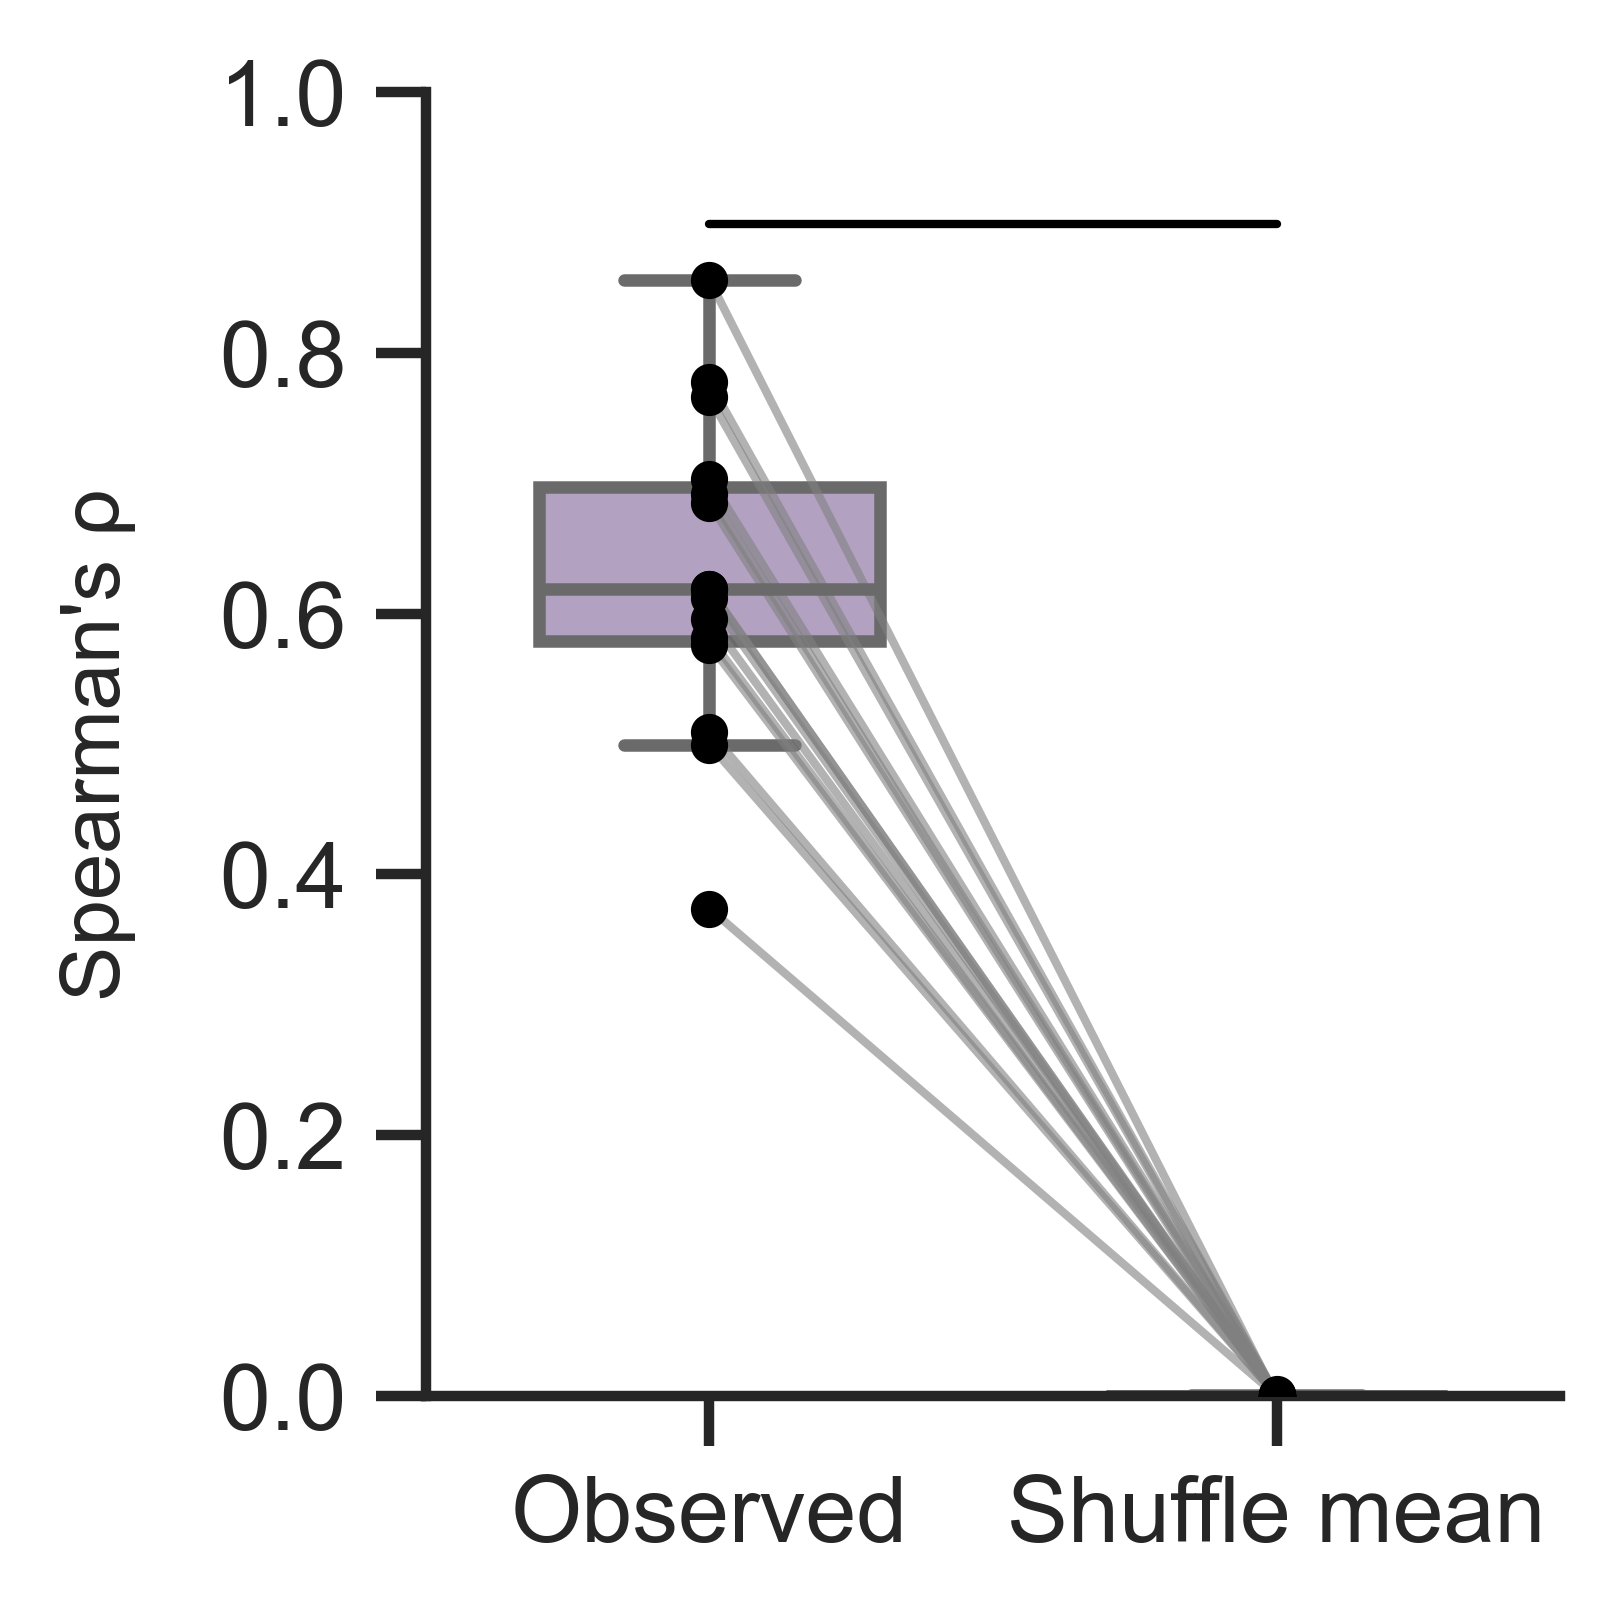

In [9]:
from scipy.stats import ttest_rel

def plot_spearman_rho_paired(
    df,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal",
    title="",
    save_path=None
):
    """
    Draws side-by-side boxplots of observed Spearman rho vs shuffle-mean rho,
    overlays paired points per animal connected by line segments,
    and annotates a paired t-test.

    Expects df to have columns: [id_col, obs_col, null_col].
    """
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial', 'figure.figsize': (3.5, 3.5)})
    sns.set(style="ticks", font="Arial")

    # Keep rows with both values present
    d = df[[id_col, obs_col, null_col]].dropna().copy()
    if d.empty:
        raise ValueError("No rows with both observed and shuffle mean rhos present.")

    # Paired t-test
    tstat, pval = ttest_rel(d[obs_col], d[null_col])

    # Long form for plotting
    long = d.melt(
        id_vars=id_col,
        value_vars=[obs_col, null_col],
        var_name="condition",
        value_name="rho"
    )
    name_map = {obs_col: "Observed", null_col: "Shuffle mean"}
    long["condition"] = long["condition"].map(name_map)

    order = ["Observed", "Shuffle mean"]  # left→right
    palette = {"Observed": "#B39BC8", "Shuffle mean": "#C9D6DF"}  # keep your original purple

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Boxplots (background)
    sns.boxplot(
        data=long, x="condition", y="rho",
        order=order, palette=palette, ax=ax,
        width=0.6, showfliers=False
    )

    # Connect each animal’s pair and plot points
    x_pos = {cond: i for i, cond in enumerate(order)}
    for animal, grp in long.groupby(id_col):
        if set(order).issubset(set(grp["condition"])):
            y0 = grp.loc[grp["condition"] == "Shuffle mean", "rho"].values[0]
            y1 = grp.loc[grp["condition"] == "Observed", "rho"].values[0]
            ax.plot(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                color="gray", alpha=0.6, linewidth=1, zorder=2
            )
            ax.scatter(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                s=12, color="black", zorder=3
            )

    # Axis labels, limits, title
    ax.set_ylabel("Spearman's ρ", fontsize=10, fontname='Arial', labelpad=10)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.set_ylim(0, 1)

    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bar + text
    y_max = long["rho"].max()
    y_min = long["rho"].min()
    span = max(1e-6, y_max - y_min)
    y_bar = y_max + 0.05 * span
    ax.plot([x_pos["Shuffle mean"], x_pos["Observed"]], [y_bar, y_bar], color="black", linewidth=1)

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (tstat, pval)

fig, ax, (t, p) = plot_spearman_rho_paired(
    df_all_results,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal"
)

plt.savefig('/Users/suthardr/Desktop/first_v_sesond/FC_crossval_rho_paired_first_v_secondhalf.svg', dpi=600, bbox_inches='tight', format='svg')

In [8]:
def run_cross_validated_analysis_second_first_half(
        animal_id, traces, timestamps, save_path_prefix,
        do_shuffle=True, n_shuffles=10000, seed=None, two_sided=True
):
    # ---------------- helpers ----------------
    def shuffle_control_test(x, y, n_shuffles=1000, seed=None, two_sided=True):
        x = np.asarray(x);
        y = np.asarray(y)
        if x.shape[0] != y.shape[0]:
            raise ValueError(f"Length mismatch: x={x.shape[0]}, y={y.shape[0]}")
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
            raise ValueError("Non-finite values in x or y")
        rng = np.random.default_rng(seed)
        r_obs, p_obs = stats.spearmanr(x, y)
        sh = np.empty(n_shuffles, dtype=float)
        for i in range(n_shuffles):
            y_perm = rng.permutation(y)
            sh[i], _ = stats.spearmanr(x, y_perm)
        if two_sided:
            p_emp = (np.sum(np.abs(sh) >= abs(r_obs)) + 1) / (n_shuffles + 1)
        else:
            if r_obs >= 0:
                p_emp = (np.sum(sh >= r_obs) + 1) / (n_shuffles + 1)
            else:
                p_emp = (np.sum(sh <= r_obs) + 1) / (n_shuffles + 1)
        return {
            "r_obs": float(r_obs),
            "p_obs_parametric": float(p_obs),
            "shuffle_rhos": sh,
            "p_empirical": float(p_emp),
            "null_mean": float(np.mean(sh)),
            "null_std": float(np.std(sh, ddof=1)),
            "z_obs_vs_null": float((r_obs - np.mean(sh)) / (np.std(sh, ddof=1) + 1e-12)),
        }

    def plot_shuffle_null(shuffle_rhos, r_obs, figsize=(3.5, 3.5), dpi=600):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        ax.hist(shuffle_rhos, bins=30, density=True)
        ax.axvline(r_obs, linestyle='--')
        ax.set_xlabel('Spearman ρ')
        ax.set_ylabel('Density')
        ax.set_title('Shuffle null (permute Y across cells)')
        return fig, ax

    # ---------------- analysis ----------------
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial'})

    # Compute ETA for shocks 1&3 and 2&4
    whole_eta_13, time_13 = onep.eta_individual_cells(traces.T, timestamps, [[240, 300]], window=28)
    whole_eta_24, time_24 = onep.eta_individual_cells(traces.T, timestamps, [[120, 180]], window=28)

    # Z-score starting at 140
    adjusted_whole_eta_1_3 = stats.zscore(whole_eta_13[:, 140:], axis=1)
    adjusted_whole_eta_2_4 = stats.zscore(whole_eta_24[:, 140:], axis=1)
    time_1_3 = time_13[140:]

    # Sort arrays by max
    sorted_array_1, idxs_13 = onep.maxsort(adjusted_whole_eta_1_3)
    sorted_array_2, idxs_24 = onep.maxsort(adjusted_whole_eta_2_4)

    # y-ticks for heatmaps
    first_last = [0, len(adjusted_whole_eta_1_3)]

    # --- Heatmaps ---
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(7, 5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.heatmap(adjusted_whole_eta_1_3[idxs_13], ax=ax1, cmap='mako', cbar=False,
                xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax1.tick_params(axis='both', which='major', labelsize=8)
    ax1.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax1.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax1.set_yticks(first_last)
    ax1.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax1.set_title('Second Half (3&4)', fontsize=10, pad=10)
    ax1.set_ylabel('Astrocyte #', fontsize=10)
    ax1.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax1, left=True, bottom=True)

    sns.heatmap(adjusted_whole_eta_1_3[idxs_24], ax=ax2, cmap='mako', cbar=True,
                cbar_kws={'label': 'Z-score'}, xticklabels=True, rasterized=True, yticklabels=True, vmin=-4, vmax=4)
    ax2.tick_params(axis='both', which='major', labelsize=8)
    ax2.set_xticks(np.linspace(0, len(time_1_3), 5))
    ax2.set_xticklabels(np.linspace(np.min(time_1_3), np.max(time_1_3), 5).astype(int), rotation=0)
    ax2.set_yticks(first_last)
    ax2.set_yticklabels([first_last[0], first_last[1]], rotation=0)
    ax2.set_title('Second Half Sorted by First Half', fontsize=10, pad=10)
    ax2.set_xlabel('Time (s)', fontsize=10)
    sns.despine(ax=ax2, left=True, bottom=True)

    plt.tight_layout(pad=3)
    heatmap_fp = f"{save_path_prefix}_heatmaps.svg"
    fig.savefig(heatmap_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # --- Argmaxes ---
    max_idxs_1_3 = np.argmax(sorted_array_1, axis=1)
    argmax_1_3 = time_1_3[max_idxs_1_3]

    odd_sorted_even = adjusted_whole_eta_1_3[idxs_24]
    sorted_idx = np.argmax(odd_sorted_even, axis=1)
    argmax_1_3_sorted_2_4 = time_1_3[sorted_idx]

    # --- Spearman correlation ---
    rho_s, p_s = stats.spearmanr(argmax_1_3, argmax_1_3_sorted_2_4)
    print(f"{animal_id} - Spearman rho: {rho_s:.4f}, p-value: {p_s:.4e}")

    # --- Shuffle control (optional) ---
    shuffle_fp = None
    shuffle_empirical_p = None
    shuffle_null_mean = None
    shuffle_null_std = None
    z_obs_vs_null = None

    if do_shuffle:
        if seed is None:
            seed = hash(str(animal_id)) & 0xFFFFFFFF
        shres = shuffle_control_test(
            argmax_1_3, argmax_1_3_sorted_2_4,
            n_shuffles=n_shuffles, seed=seed, two_sided=two_sided
        )
        print(f"{animal_id} - shuffle null: mean={shres['null_mean']:.4f}, "
              f"sd={shres['null_std']:.4f}, empirical p={shres['p_empirical']:.4g}, "
              f"z={shres['z_obs_vs_null']:.2f}")
        fig_shuf, ax_shuf = plot_shuffle_null(shres["shuffle_rhos"], shres["r_obs"])
        shuffle_fp = f"{save_path_prefix}_shuffle_null.svg"
        fig_shuf.savefig(shuffle_fp, dpi=600, bbox_inches='tight')
        plt.close(fig_shuf)

        shuffle_empirical_p = shres["p_empirical"]
        shuffle_null_mean = shres["null_mean"]
        shuffle_null_std = shres["null_std"]
        z_obs_vs_null = shres["z_obs_vs_null"]

    # --- Regression data (clean) ---
    df = pd.DataFrame({
        'Argmax Second sorted Second': argmax_1_3,
        'Argmax Second sorted First': argmax_1_3_sorted_2_4
    })
    x_name = 'Argmax Second sorted Second'
    y_name = 'Argmax Second sorted First'
    _df = df[[x_name, y_name]].copy()
    _df = _df[np.isfinite(_df[x_name]) & np.isfinite(_df[y_name])]
    x = _df[x_name].to_numpy()
    y = _df[y_name].to_numpy()
    X = sm.add_constant(x)

    # --- Fit RLM ---
    model = sm.RLM(y, X).fit()

    # ---- R^2 variants ----
    y_pred = np.asarray(model.fittedvalues)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_var = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # guard for degenerate correlation
    try:
        r2_corr = float(np.corrcoef(y, y_pred)[0, 1] ** 2)
    except Exception:
        r2_corr = np.nan

    rho_rlm = model.model.M.rho
    scale = getattr(model, "scale", 1.0) or 1.0
    resid_fit_scaled = (y - y_pred) / scale
    resid_null_scaled = (y - float(np.mean(y))) / scale
    loss_fit = float(np.sum(rho_rlm(resid_fit_scaled)))
    loss_null = float(np.sum(rho_rlm(resid_null_scaled)))
    r2_pseudo_robust = 1 - (loss_fit / loss_null) if loss_null > 0 else np.nan

    # ---- Extract flattened params ----
    beta = np.asarray(model.params)  # [intercept, slope]
    pvals = np.asarray(model.pvalues)  # [p_intercept, p_slope]
    intercept = float(beta[0]) if beta.size > 0 else np.nan
    slope = float(beta[1]) if beta.size > 1 else np.nan
    p_value_bias = float(pvals[0]) if pvals.size > 0 else np.nan
    p_value_slope = float(pvals[1]) if pvals.size > 1 else np.nan

    # --- Plot: scatter + RLM line + 95% CI (bootstrap with fallback) ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)
    sns.set(style="ticks", font="Arial")
    sns.scatterplot(data=_df, x=x_name, y=y_name, color='#231f20', ax=ax)

    x_grid = np.linspace(x.min(), x.max(), 200)
    X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
    y_hat = X_grid @ np.asarray(model.params)
    ax.plot(x_grid, y_hat, color='#231f20', lw=2, label='RLM fit')

    n_boot = 1000
    min_ok = 100
    rng = np.random.default_rng(12345)
    y_boot = np.full((n_boot, x_grid.size), np.nan, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, len(_df), size=len(_df))
        xb = x[idx];
        yb = y[idx]
        Xb = sm.add_constant(xb)
        try:
            mb = sm.RLM(yb, Xb).fit()
            y_boot[b, :] = X_grid @ np.asarray(mb.params)
        except Exception:
            pass

    counts = np.sum(np.isfinite(y_boot), axis=0)
    lower = np.full_like(y_hat, np.nan)
    upper = np.full_like(y_hat, np.nan)
    ok = counts >= min_ok
    if np.any(ok):
        lower[ok] = np.nanpercentile(y_boot[:, ok], 2.5, axis=0)
        upper[ok] = np.nanpercentile(y_boot[:, ok], 97.5, axis=0)

    if np.any(~ok):
        covb = np.asarray(model.cov_params())
        se_mean = np.sqrt(np.sum(X_grid @ covb * X_grid, axis=1))
        z = stats.norm.ppf(0.975)
        lower_analytic = y_hat - z * se_mean
        upper_analytic = y_hat + z * se_mean
        lower[~ok] = lower_analytic[~ok]
        upper[~ok] = upper_analytic[~ok]

    ax.fill_between(x_grid, lower, upper, alpha=0.2, label='95% CI')
    ax.set_xlabel('Argmax Second Sorted Second (s)', fontsize=10, fontname="Arial")
    ax.set_ylabel('Argmax Second Sorted First (s)', fontsize=10, fontname='Arial')
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 25)
    ax.set_xlim(0, 25)
    sns.despine(ax=ax)
    ax.legend(frameon=False)

    scatter_fp = f"{save_path_prefix}_scatter.svg"
    fig.savefig(scatter_fp, dpi=600, bbox_inches='tight')
    plt.close(fig)

    # ---- Return flattened summary ----
    return {
        "animal": animal_id,
        "spearman_rho": float(rho_s),
        "spearman_p": float(p_s),
        "slope": slope,
        "intercept": intercept,
        "p_value_slope": p_value_slope,
        "p_value_bias": p_value_bias,
        "r2_var": float(r2_var),
        "r2_corr": float(r2_corr) if np.isfinite(r2_corr) else np.nan,
        "r2_pseudo_robust": float(r2_pseudo_robust) if np.isfinite(r2_pseudo_robust) else np.nan,
        "heatmap_fp": heatmap_fp,
        "scatter_fp": scatter_fp,
        "shuffle_hist_fp": shuffle_fp,
        "shuffle_empirical_p": shuffle_empirical_p,
        "shuffle_null_mean": shuffle_null_mean,
        "shuffle_null_std": shuffle_null_std,
        "shuffle_z": z_obs_vs_null,
    }


In [9]:

# ===================== batch runner =====================

trace_lookup = {mouse: globals()[mouse] for mouse in mouse_ids}

all_results = []
save_dir = '/Users/suthardr/Desktop/second_v_first'

for mouse in mouse_ids:
    print(f"Processing {mouse}...")
    traces = trace_lookup[mouse]
    timestamps = collection_fc.animals[mouse].Timestamps[:3303]
    res = run_cross_validated_analysis_second_first_half(
        animal_id=mouse,
        traces=traces,
        timestamps=timestamps,
        save_path_prefix=f"{save_dir}/FC_crossvalled_{mouse}"
    )
    all_results.append(res)

df_all_results = pd.DataFrame(all_results)

# put 'animal' first if present
if 'animal' in df_all_results.columns:
    cols = ['animal'] + [c for c in df_all_results.columns if c != 'animal']
    df_all_results = df_all_results[cols]

print(df_all_results)
df_all_results.to_csv(f'{save_dir}/crossval_summary_results.csv', index=False)
print(f"Saved: {save_dir}/crossval_summary_results.csv")
df_all_results

Processing astroF3...
astroF3 - Spearman rho: 0.5045, p-value: 1.9846e-09
astroF3 - shuffle null: mean=-0.0002, sd=0.0906, empirical p=9.999e-05, z=5.57
Processing astroF5...
astroF5 - Spearman rho: 0.7013, p-value: 3.4475e-30
astroF5 - shuffle null: mean=-0.0003, sd=0.0720, empirical p=9.999e-05, z=9.74
Processing astroF6...
astroF6 - Spearman rho: 0.8538, p-value: 1.8043e-55
astroF6 - shuffle null: mean=0.0009, sd=0.0730, empirical p=9.999e-05, z=11.68
Processing astroF7...
astroF7 - Spearman rho: 0.7703, p-value: 8.8920e-27
astroF7 - shuffle null: mean=-0.0006, sd=0.0878, empirical p=9.999e-05, z=8.78
Processing astroF8...
astroF8 - Spearman rho: 0.7026, p-value: 2.7283e-47
astroF8 - shuffle null: mean=-0.0014, sd=0.0569, empirical p=9.999e-05, z=12.38
Processing astroF9...
astroF9 - Spearman rho: 0.6097, p-value: 5.2462e-31
astroF9 - shuffle null: mean=0.0003, sd=0.0586, empirical p=9.999e-05, z=10.39
Processing astroF10...
astroF10 - Spearman rho: 0.6231, p-value: 2.4794e-23
astro

,animal,spearman_rho,spearman_p,slope,intercept,p_value_slope,p_value_bias,r2_var,r2_corr,r2_pseudo_robust,heatmap_fp,scatter_fp,shuffle_hist_fp,shuffle_empirical_p,shuffle_null_mean,shuffle_null_std,shuffle_z
0,astroF3,0.504520,1.984624e-09,0.417679,1.603783,1.263410e-16,1.484523e-25,0.021353,0.055123,0.123239,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000227,0.090616,5.570183
1,astroF5,0.701330,3.447521e-30,0.564786,1.315955,1.966430e-150,3.483300e-65,0.155692,0.178991,0.335438,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000340,0.072028,9.741566
2,astroF6,0.853777,1.804275e-55,0.976086,0.070082,0.000000e+00,1.325075e-02,0.254869,0.382670,0.523013,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,0.000902,0.072998,11.683468
3,astroF7,0.770289,8.892040e-27,0.883051,0.348733,4.589427e-215,8.505216e-05,0.675038,0.678633,0.515226,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000600,0.087822,8.777840
4,astroF8,0.702641,2.728281e-47,0.706967,1.183662,6.270139e-297,3.671631e-43,0.242397,0.275628,0.389697,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.001422,0.056892,12.375359
5,astroF9,0.609662,5.246214e-31,0.692483,1.195449,0.000000e+00,3.912198e-29,0.342360,0.355319,0.364506,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,0.000309,0.058622,10.394619
6,astroF10,0.623103,2.479431e-23,0.835661,0.711475,0.000000e+00,3.517812e-17,0.413679,0.443116,0.463277,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000412,0.069994,8.908088
7,astroM3,0.618771,8.218386e-19,0.585388,1.612866,2.891426e-89,2.653205e-24,0.268982,0.285534,0.342330,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000470,0.077278,8.013179
8,astroM4,0.575895,1.078012e-25,0.556751,1.641525,2.233125e-56,1.428387e-22,0.235814,0.247385,0.305918,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,0.001070,0.060316,9.530267
9,astroM5,0.500418,1.171621e-19,0.447844,2.743133,3.903727e-30,9.669046e-30,0.100479,0.118233,0.181388,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,/Users/suthardr/Desktop/second_v_first/FC_cros...,0.0001,-0.000410,0.059179,8.463000


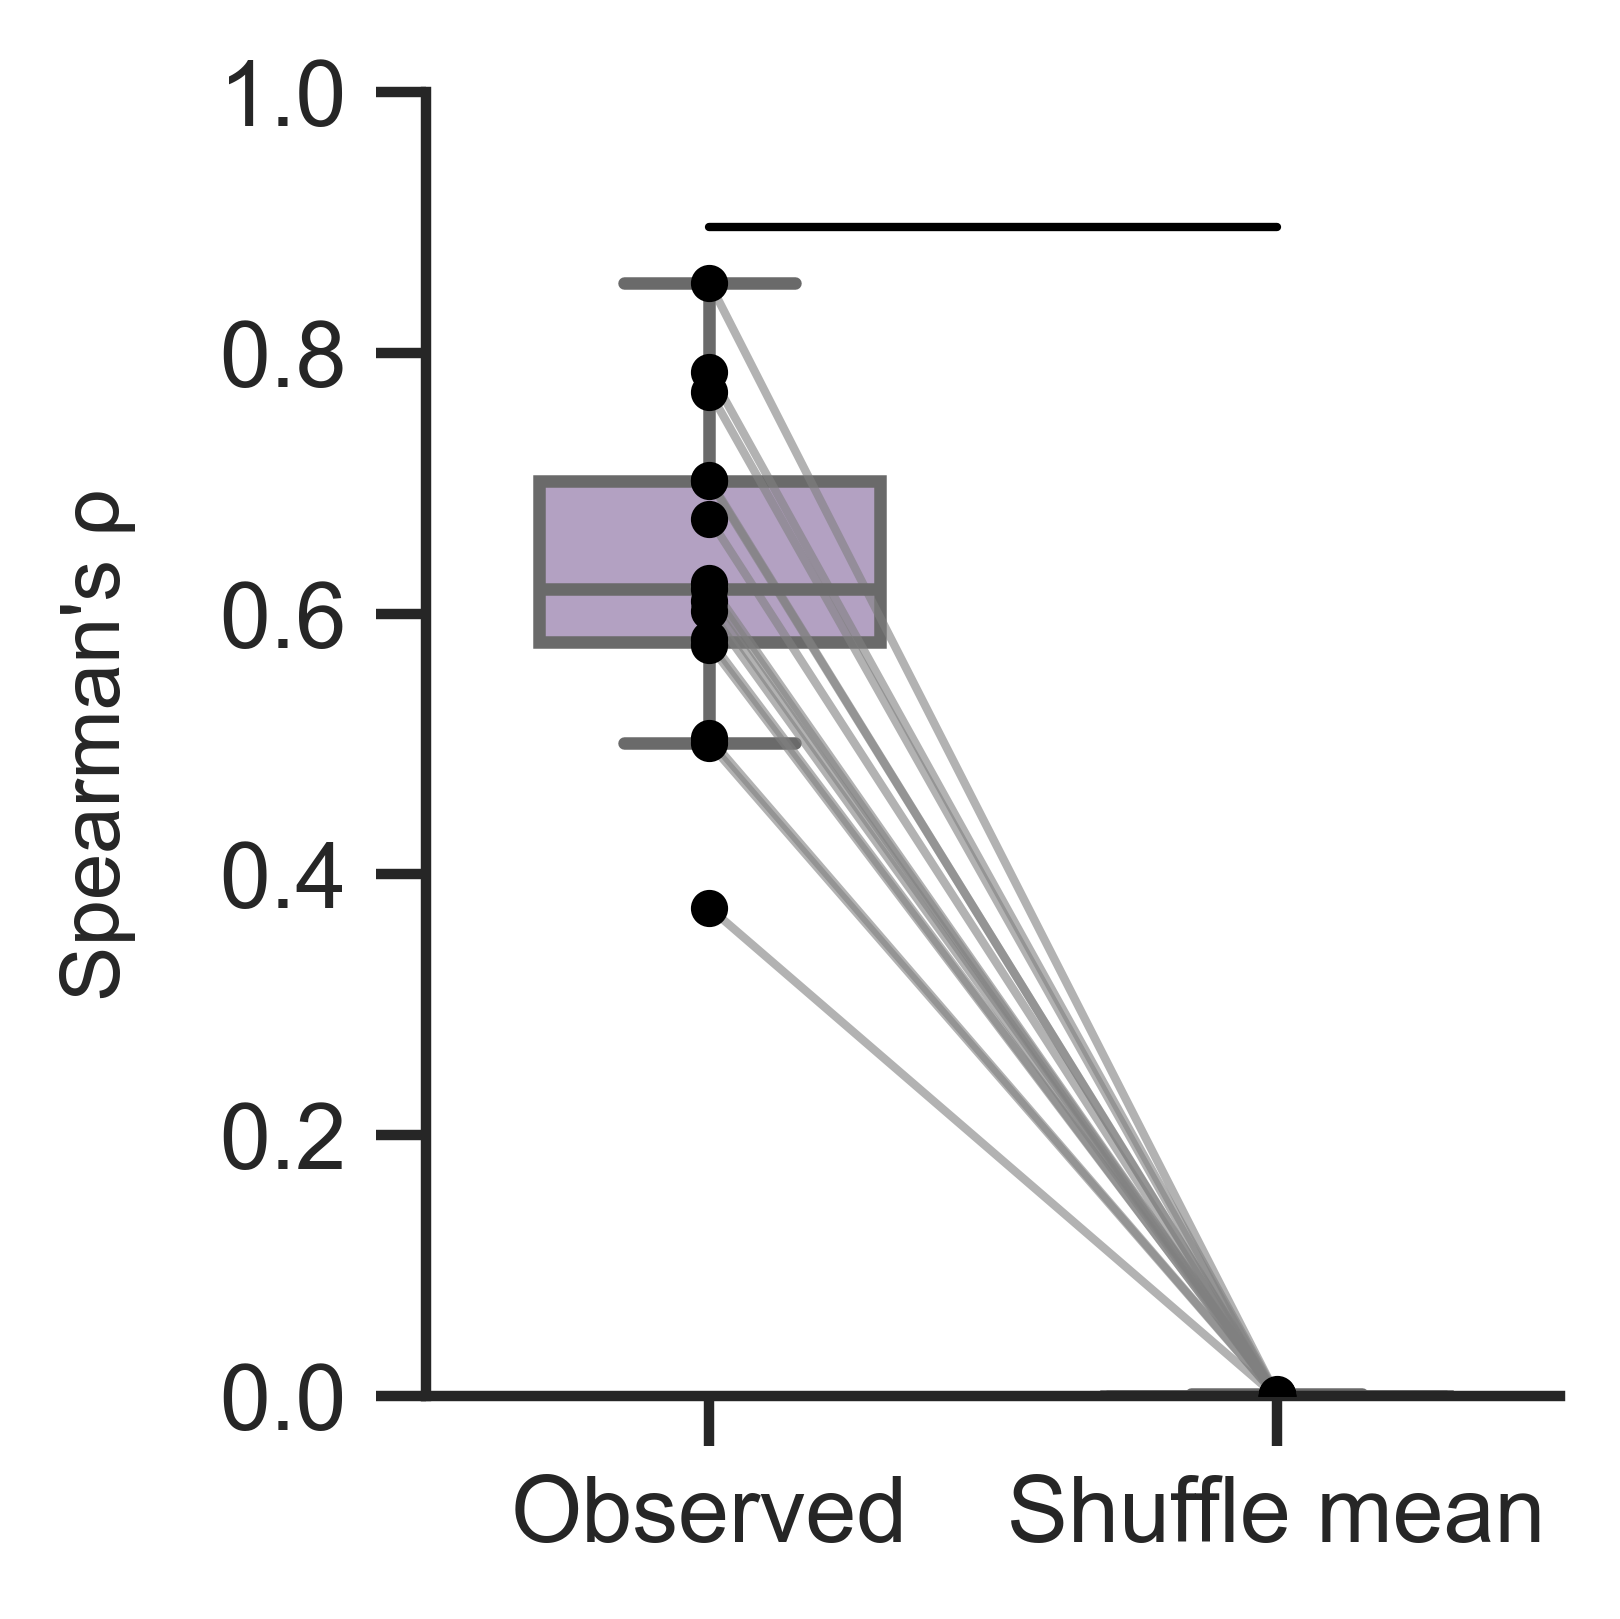

In [7]:

from scipy.stats import ttest_rel


def plot_spearman_rho_paired(
        df,
        obs_col="spearman_rho",
        null_col="shuffle_null_mean",
        id_col="animal",
        title="",
        save_path=None
):
    """
    Draws side-by-side boxplots of observed Spearman rho vs shuffle-mean rho,
    overlays paired points per animal connected by line segments,
    and annotates a paired t-test.

    Expects df to have columns: [id_col, obs_col, null_col].
    """
    plt.rcParams.update({'font.size': 8, 'font.family': 'Arial', 'figure.figsize': (3.5, 3.5)})
    sns.set(style="ticks", font="Arial")

    # Keep rows with both values present
    d = df[[id_col, obs_col, null_col]].dropna().copy()
    if d.empty:
        raise ValueError("No rows with both observed and shuffle mean rhos present.")

    # Paired t-test
    tstat, pval = ttest_rel(d[obs_col], d[null_col])

    # Long form for plotting
    long = d.melt(
        id_vars=id_col,
        value_vars=[obs_col, null_col],
        var_name="condition",
        value_name="rho"
    )
    name_map = {obs_col: "Observed", null_col: "Shuffle mean"}
    long["condition"] = long["condition"].map(name_map)

    order = ["Observed", "Shuffle mean"]  # left→right
    palette = {"Observed": "#B39BC8", "Shuffle mean": "#C9D6DF"}  # keep your original purple

    fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=600)

    # Boxplots (background)
    sns.boxplot(
        data=long, x="condition", y="rho",
        order=order, palette=palette, ax=ax,
        width=0.6, showfliers=False
    )

    # Connect each animal’s pair and plot points
    x_pos = {cond: i for i, cond in enumerate(order)}
    for animal, grp in long.groupby(id_col):
        if set(order).issubset(set(grp["condition"])):
            y0 = grp.loc[grp["condition"] == "Shuffle mean", "rho"].values[0]
            y1 = grp.loc[grp["condition"] == "Observed", "rho"].values[0]
            ax.plot(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                color="gray", alpha=0.6, linewidth=1, zorder=2
            )
            ax.scatter(
                [x_pos["Shuffle mean"], x_pos["Observed"]],
                [y0, y1],
                s=12, color="black", zorder=3
            )

    # Axis labels, limits, title
    ax.set_ylabel("Spearman's ρ", fontsize=10, fontname='Arial', labelpad=10)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=10, pad=10, fontname='Arial')
    ax.set_ylim(0, 1)

    sns.despine(ax=ax)
    plt.tight_layout(pad=3)

    # Significance bar + text
    y_max = long["rho"].max()
    y_min = long["rho"].min()
    span = max(1e-6, y_max - y_min)
    y_bar = y_max + 0.05 * span
    ax.plot([x_pos["Shuffle mean"], x_pos["Observed"]], [y_bar, y_bar], color="black", linewidth=1)

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')

    return fig, ax, (tstat, pval)


fig, ax, (t, p) = plot_spearman_rho_paired(
    df_all_results,
    obs_col="spearman_rho",
    null_col="shuffle_null_mean",
    id_col="animal"
)

plt.savefig('/Users/suthardr/Desktop/second_v_first/FC_crossval_rho_paired_second_v_firsthalf.svg', dpi=600,
            bbox_inches='tight', format='svg')
